# 01 — EDA overview

1. Считывание метаданные (разрешение, FPS, длительность) **6 видеофайлов** робота-обходчика
2. Загрузка **3 ground-truth CSV** с разметкой 157 ценников и собираем их в единый DataFrame `gt`.
3. Считание **статистики полей** — какие распознаваемые, какие почти всегда `"нет"`.
4. Анализ **плотности ценников на кадр** и **размер bbox** 

**Output:** DataFrame `gt_merged.csv`

**Input:**
- `Данные/{25_12-20,26_12-20,43_15}/*.mp4` + `*.csv` — размеченные
- `Данные/Unlabeled/*.mp4` — без разметки
- `Khasan_Dataset/` — отдельный размеченный набор (301 кадр с полигонами) — используется для обучения детектора.


In [22]:
import sys, json
from pathlib import Path
import cv2
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
DATA = ROOT / 'Данные'

## 1. Разрешение, FPS, длительность, кодек

In [23]:
videos = sorted(DATA.rglob('*.mp4'))

rows = []

for path in videos:
    cap = cv2.VideoCapture(str(path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = int(cap.get(cv2.CAP_PROP_FOURCC))

    cap.release()

    codec = ''.join(chr((fourcc >> 8 * i) & 0xFF) for i in range(4))
    duration_s = round(frames / fps, 1) if fps else None

    rows.append({
        'path': path.relative_to(ROOT).as_posix(),
        'size_mb': round(path.stat().st_size / 1e6, 1),
        'w': w,
        'h': h,
        'fps': round(fps, 2),
        'frames': frames,
        'duration_s': duration_s,
        'codec': codec,
    })

df_v = pd.DataFrame(rows)
df_v

,path,size_mb,w,h,fps,frames,duration_s,codec
0,Данные/25_12-20/25_12-20.mp4,77.5,3840,2160,19.58,823,42.0,h264
1,Данные/26_12-20/26_12-20.mp4,140.4,3840,2160,19.98,1776,88.9,h264
2,Данные/43_15/43_15.mp4,23.5,3840,2160,19.95,299,15.0,h264
3,Данные/Unlabeled/25_12-20.mp4,64.6,3840,2160,19.96,865,43.3,h264
4,Данные/Unlabeled/26_12-20.mp4,51.1,3840,2160,20.01,634,31.7,h264
5,Данные/Unlabeled/26_2-10.mp4,49.3,3840,2160,20.00,613,30.6,h264


## 2. Ground-truth CSV

In [24]:
BBOX_COLS = ['x_min', 'y_min', 'x_max', 'y_max']

csvs = sorted(DATA.rglob('*.csv'))
tables = []

for csv_path in csvs:
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)

    # чистим названия колонок
    df.columns = df.columns.str.strip()

    # исправляем опечатку в названии колонки
    df = df.rename(columns={
        'wholesale_level_1_coun': 'wholesale_level_1_count'
    })

    # чистим filename
    df['filename'] = df['filename'].str.strip()

    # добавляем имя видео-источника
    df['source_video'] = csv_path.with_suffix('.mp4').relative_to(ROOT).as_posix()

    # переводим координаты bbox в числа
    for col in BBOX_COLS:
        df[col + '_f'] = (
            df[col]
            .str.strip()
            .str.replace(',', '.', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )

    # переводим timestamp в число
    df['frame_timestamp_ms'] = (
        df['frame_timestamp']
        .str.strip()
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
        .astype('Int64')
    )

    tables.append(df)

gt = pd.concat(tables, ignore_index=True)

print(f'TOTAL: {len(gt)} tags from {len(csvs)} CSVs')

gt[
    ['source_video', 'filename', 'product_name', 'price_default', 'frame_timestamp_ms']
    + [col + '_f' for col in BBOX_COLS]
].head(8)

TOTAL: 157 tags from 3 CSVs


,source_video,filename,product_name,price_default,frame_timestamp_ms,x_min_f,y_min_f,x_max_f,y_max_f
0,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63",0,2063.1,1929.8,2296.6,2126.1
1,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63",0,2098.8,1428.5,2348.7,1663.4
2,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99",0,2125.1,979.1,2374.1,1258.3
3,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99",0,2148.0,419.0,2412.5,957.2
4,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36",5745,2061.3,1896.0,2296.9,2101.5
5,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Вино безалкогольное MAYBACH роз. п/сух. (Герма...,"1263,15",0,657.7,1779.6,868.9,1969.5
6,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Вино безалкогольное MAYBACH бел. п/сух. (Герма...,"1263,15",0,593.9,1330.8,804.3,1553.7
7,Данные/25_12-20/25_12-20.mp4,25_12-20/2.mp4,Вино безалкогольное MUCHO MAS бел. п/сух. (Исп...,"1068,42",0,581.4,1009.6,805.1,1301.5


- `filename` — имя видеофайла из CSV
- `source_video` — путь до видеофайла.
- `frame_timestamp` / `frame_timestamp_ms` — на каком кадре виден ценник (мс от начала). `_ms`-версия — числовой парсинг.
- `x_min`, `y_min`, `x_max`, `y_max` — координаты прямоугольника ценника на 4K-кадре 

- `product_name` — название товара
- `price_default` — цена без карты лояльности
- `price_card` — цена по карте лояльности
- `price_discount` — цена по акции (на красных промо почти всегда `нет`)
- `barcode` — штрихкод EAN-13 (13 цифр, напечатан под полосатым кодом).
- `discount_amount` — размер скидки в круге, со знаком, например `-48%`
- `id_sku` — артикул товара
- `print_datetime` — дата и время печати ценника
- `code` — код зоны выкладки
- `additional_info` — доп. инфа (`Сухое`, `Полусладкое`, `3 по цене 2`).
- `color` — цвет ценника
- `special_symbols` — тип выкладки

**Поля из QR-кода** — QR содержит payload типа `barcode=...&price1=...&p4=...&aP=`. Из него парсятся 12 полей:
- `qr_code_barcode` — штрихкод из QR (должен совпадать с `barcode`)
- `price1_qr` … `price4_qr` — 4 цены из QR
- `wholesale_level_1_count` / `wholesale_level_1_price` — оптовый порог 1: количество и цена
- `wholesale_level_2_count` / `wholesale_level_2_price` — оптовый порог 2
- `action_price_qr` / `action_code_qr` — акционная цена и код акции.


- `"нет"` — поле **структурно отсутствует** на этом типе ценника (например, у красного промо нет блока `price_discount`).
- `""` (пусто) — поле **должно быть**, но не распознано.
- Любое другое — распознанное значение.

## 3. Статистики по полям

Считаем для каждого поля три числа:
- **present** — поле распознано
- **нет** — поле отсутствует на этом ценнике.
- **empty** — поле должно было быть, но не распознано

Колонка `recall%` = `present / (present + empty)` показывает, какую долю **видимых** полей разметчики смогли распознать

In [25]:
FIELDS = [
    'product_name', 'price_default', 'price_card', 'price_discount', 'barcode',
    'discount_amount', 'id_sku', 'print_datetime', 'code', 'additional_info',
    'color', 'special_symbols', 'qr_code_barcode', 'price1_qr', 'price2_qr',
    'price3_qr', 'price4_qr', 'wholesale_level_1_count', 'wholesale_level_1_price',
    'wholesale_level_2_count', 'wholesale_level_2_price', 'action_price_qr', 'action_code_qr',
]

rows = []

for field in FIELDS:
    if field in gt.columns:
        s = gt[field].fillna('')

        present_count = ((s != '') & (s != 'нет')).sum()
        no_count = (s == 'нет').sum()
        empty_count = (s == '').sum()

    else:
        present_count = 0
        no_count = 0
        empty_count = 0

    rows.append({
        'field': field,
        'present': int(present_count),
        'нет': int(no_count),
        'empty': int(empty_count),
    })

df_stats = pd.DataFrame(rows)

df_stats['recall%'] = (
    df_stats['present'] / (df_stats['present'] + df_stats['empty']) * 100
).round(1)

df_stats

,field,present,нет,empty,recall%
0,product_name,157,0,0,100.0
1,price_default,156,1,0,100.0
2,price_card,154,3,0,100.0
3,price_discount,1,156,0,100.0
4,barcode,153,3,1,99.4
5,discount_amount,154,3,0,100.0
6,id_sku,151,3,3,98.1
7,print_datetime,102,4,51,66.7
8,code,124,24,9,93.2
9,additional_info,91,66,0,100.0


### Значения в ключевых категориальных полях

Анализ распределения `color`, `special_symbols`, `code` и `filename`

In [26]:
print('Colors:', gt['color'].value_counts().to_dict())
print('Special symbols:', gt['special_symbols'].value_counts().to_dict())
print('\nTop codes:', gt['code'].value_counts().head(10).to_dict())
print('\nFilenames (unique values per CSV):')
print(gt.groupby('source_video')['filename'].unique())

Colors: {'red': 156, 'yellow': 1}
Special symbols: {'К': 75, 'Ш': 52, 'нет': 30}

Top codes: {'нет': 24, '13_043015': 24, '01_025019': 17, '01_025017': 13, '': 9, '01_026015 - 026016': 7, '026005 - 026007': 6, '026017 - 025018': 5, '025005 - 026007': 4, '025017 - 026018': 4}

Filenames (unique values per CSV):
source_video
Данные/25_12-20/25_12-20.mp4    [25_12-20/2.mp4]
Данные/26_12-20/26_12-20.mp4      [26_12-20.mp4]
Данные/43_15/43_15.mp4               [43_15.mp4]
Name: filename, dtype: object


- `color`: 156 red, 1 yellow — в датасете почти только промо - ценники
- `special_symbols`: 3 класса (К=75, Ш=52, нет=30)
- `price_discount`: 156 из 157 = "нет". На красном промо-ценнике этого блока нет.
- `print_datetime`: 51 пустое значение
- `code`: 24 "нет" + 9 empty

## 4. Сводка ценников на кадр

In [27]:
keys = gt.groupby(['source_video', 'frame_timestamp_ms']).size().rename('n_tags')
print('Уникальных keyframe-меток по видео:')
print(gt.groupby('source_video')['frame_timestamp_ms'].nunique())
print('\nРаспределение ценников на keyframe:')
keys.describe().to_frame().T

Уникальных keyframe-меток по видео:
source_video
Данные/25_12-20/25_12-20.mp4    10
Данные/26_12-20/26_12-20.mp4    15
Данные/43_15/43_15.mp4           2
Name: frame_timestamp_ms, dtype: int64

Распределение ценников на keyframe:


,count,mean,std,min,25%,50%,75%,max
n_tags,27.0,5.814815,3.486645,1.0,4.0,5.0,7.5,16.0


In [28]:
keys.value_counts().sort_index().to_frame('n_keyframes_with_k_tags')

,n_keyframes_with_k_tags
n_tags,
1,3
2,1
3,2
4,4
5,5
6,2
7,3
8,2
9,3


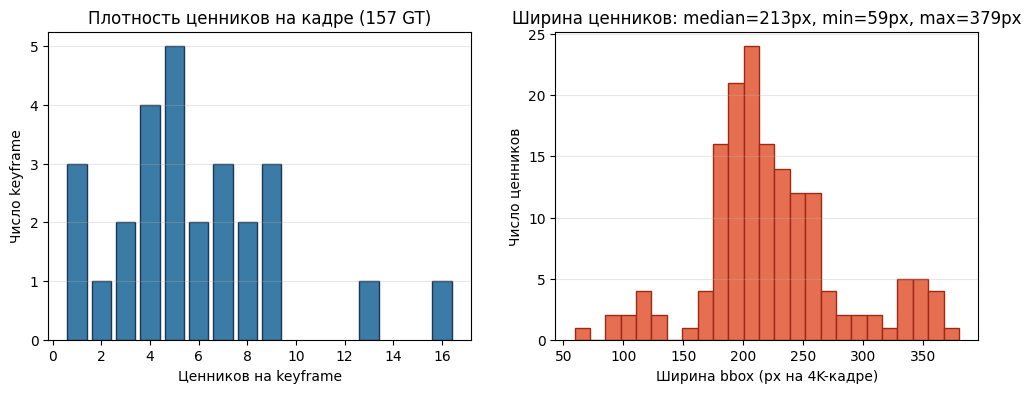

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Распределение «сколько ценников на одном keyframe»
counts = keys.value_counts().sort_index()
axes[0].bar(counts.index.astype(int), counts.values, color='#3a7ca5', edgecolor='#1d3557')
axes[0].set_xlabel('Ценников на keyframe')
axes[0].set_ylabel('Число keyframe')
axes[0].set_title('Плотность ценников на кадре (157 GT)')
axes[0].grid(axis='y', alpha=0.3)

# 2) Распределение ширины bbox в пикселях 4K
widths = gt['x_max_f'] - gt['x_min_f']
axes[1].hist(widths.dropna(), bins=25, color='#e76f51', edgecolor='#9c2a14')
axes[1].set_xlabel('Ширина bbox (px на 4K-кадре)')
axes[1].set_ylabel('Число ценников')
axes[1].set_title(f'Ширина ценников: median={int(widths.median())}px, '
                  f'min={int(widths.min())}px, max={int(widths.max())}px')
axes[1].grid(axis='y', alpha=0.3)

plt.show()

## 5. Sanity-check — bbox-ы на реальных кадрах

Берём по одному размеченному keyframe из каждого видео, рисуем поверх GT-боксы — проверяем, что координаты из CSV корректно совпадают с ценниками на кадре.

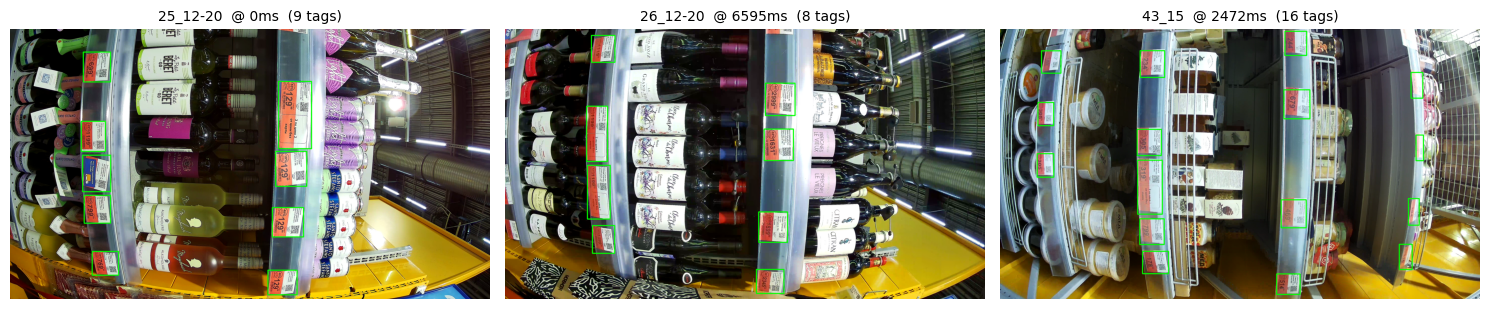

In [30]:
import matplotlib.pyplot as plt

def grab_frame(path, ts_ms, fps, total_frames):
    cap = cv2.VideoCapture(str(path))
    cap.set(cv2.CAP_PROP_POS_MSEC, float(ts_ms))
    ok, frame = cap.read()
    if not ok:
        idx = int(round(ts_ms / 1000.0 * fps))
        for fi in [idx, idx - 1, idx - 5, idx - 10]:
            if 0 <= fi < total_frames:
                cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
                ok, frame = cap.read()
                if ok:
                    break
    cap.release()
    return frame if ok else None

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (video_path, sub) in zip(axes, gt.groupby('source_video')):
    ts = int(sub['frame_timestamp_ms'].iloc[0])
    cap = cv2.VideoCapture(str(ROOT / video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    frame = grab_frame(ROOT / video_path, ts, fps, n_frames)
    if frame is None:
        continue
    img = frame[..., ::-1].copy()
    for _, r in sub[sub['frame_timestamp_ms'] == ts].iterrows():
        x0, y0 = int(r['x_min_f']), int(r['y_min_f'])
        x1, y1 = int(r['x_max_f']), int(r['y_max_f'])
        cv2.rectangle(img, (x0, y0), (x1, y1), (0, 255, 0), 8)
    ax.imshow(img)
    ax.set_title(f"{Path(video_path).stem}  @ {ts}ms  ({len(sub[sub['frame_timestamp_ms']==ts])} tags)", fontsize=10)
    ax.axis('off')
    
plt.tight_layout()
plt.show()
